# Fine tunning pretrained model
This project aims to refine a pretrained text summarization model to enhance its ability to generate concise and coherent summaries of biomedical articles. Leveraging the PubMed Central® (PMC) database, which provides a rich archive of full-text biomedical and life sciences literature, the project will fine-tune the model to better summarize complex scientific texts.
## The process will involve:
### Data Processing:

1. **find dataset Dataset:** The dataset is sourced from PubMed Central® (PMC), a comprehensive repository of biomedical and life sciences journal literature hosted by the U.S. National Institutes of Health's National Library of Medicine. PMC serves as a crucial resource for contemporary biomedical and health care research and supports future scholarly endeavors. The dataset includes a diverse range of articles, which are available in XML format.
2. **Bulk Download and Conversion:**
    - **Bulk Download and Conversion:** The initial step involved bulk downloading XML files from PMC. These files were then processed and converted into JSON format, focusing on extracting two key components:

        - **Summary:** Derived from the abstract section of each article.
        - **Body:** The full text of the article body, excluding the abstract.
3. **Common Data Cleaning Steps:**
   - **Remove Non-ASCII Characters:** To ensure compatibility and consistency, any non-ASCII characters were removed from the text.
   - **Remove XML Tags:** Tags from the XML files were stripped out to clean the text and ensure it only contains relevant content.
   - **Add Proper Spaces and Newlines:** Text formatting was adjusted to include appropriate spaces and newlines, improving readability and consistency.

4. **Data Cleaning Approaches:** Four distinct cleaning approaches were applied to prepare the data for model fine-tuning:

   - **Approach 1:**
     - Lemmatization of both abstract and body text.
     - Removal of stopwords from both abstract and body.
     - Exclusion of the abstract content from the body text to avoid redundancy.

   - **Approach 2:**
     - Lemmatization of only the body text.
     - Removal of stopwords from the body text.
     - Exclusion of the abstract content from the body text.

   - **Approach 3:**
     - Lemmatization of both abstract and body text.
     - Removal of stopwords from both abstract and body.
     - Retention of the full body text including the abstract.

   - **Approach 4:**
     - Lemmatization of only the body text.
     - Removal of stopwords from the body text.
     - Retention of the abstract in the body text.

   - **Approach 5:**
     - Exclusion of the abstract content from the body text.

### Pretrained Model Selection:
To determine the most effective model for summarizing biomedical texts, several state-of-the-art pretrained models are evaluated:

1. **BART (Bidirectional and Auto-Regressive Transformers):** Known for its strong performance in text generation and summarization tasks, BART combines bidirectional context encoding with autoregressive text generation, making it suitable for handling complex biomedical texts.

2. **BigBird-PEGASUS (Google/BigBird-PEGASUS-Large):** This combined model leverages the strengths of both BigBird and PEGASUS. BigBird enhances the handling of long documents with its sparse attention mechanisms, while PEGASUS offers a pretraining strategy optimized for abstractive summarization. This integration is particularly effective for generating informative summaries from lengthy biomedical literature.

3. **Longformer:** Engineered to manage long documents, Longformer uses sparse attention mechanisms to handle lengthy texts efficiently, making it a strong candidate for summarizing in-depth biomedical articles.



### Model Fine-Tuning

Once the most suitable pretrained model is selected, the fine-tuning process will be conducted to enhance its summarization performance:

1. **Model Initialization:** Load the pretrained model and tokenizer. Ensure that the model's architecture and tokenization process are compatible with the data.

2. **Dataset Preparation:** Split the dataset into training, validation, and test sets. The training set will be used to fine-tune the model, the validation set to monitor performance and adjust hyperparameters, and the test set to evaluate final performance.

3. **Fine-Tuning:**
   - **Set Hyperparameters:** Define hyperparameters such as learning rate, batch size, and number of training epochs. These parameters will be optimized to balance performance and training efficiency.
   - **Training:** Train the model using the training dataset. Employ techniques such as gradient clipping and learning rate scheduling to improve training stability.
   - **Validation:** Continuously evaluate the model on the validation set to monitor performance and make necessary adjustments. This includes tuning hyperparameters and preventing overfitting.

### Evaluation

Evaluating a summarization model involves assessing both the pretrained models and the fine-tuned model to ensure that the summaries generated are accurate, coherent, and relevant. The evaluation process can be divided into several key steps:

1. **Performance Metrics:**

   - **ROUGE (Recall-Oriented Understudy for Gisting Evaluation):**
     - **ROUGE-N:** Measures the overlap of n-grams (e.g., unigrams, bigrams) between the generated summary and reference summaries. It provides insight into how well the model captures important content.
     - **ROUGE-L:** Evaluates the longest common subsequence between the generated summary and reference summaries, assessing the fluency and coherence of the summary.
     - **ROUGE-S:** Focuses on the overlap of skip-bigrams, which helps capture important phrases even if they are not contiguous.

   - **BLEU (Bilingual Evaluation Understudy):**
     - Measures the precision of n-grams in the generated summary compared to the reference summaries. It is commonly used in machine translation but can also be applied to summarization tasks to assess the overlap of phrases.

   - **METEOR (Metric for Evaluation of Translation with Explicit ORdering):**
     - Considers synonymy, stemming, and paraphrasing, in addition to precision and recall. It aims to provide a more nuanced evaluation by capturing variations in language use.

   - **BERTScore:**
     - Utilizes contextual embeddings from BERT to evaluate the similarity between the generated summary and reference summaries. BERTScore accounts for semantic similarity and helps measure how well the generated summary preserves the meaning of the original text.

2. **Human Evaluation:**

   - **Coherence and Fluency:** Assess whether the generated summaries are coherent and flow naturally. Human evaluators examine whether the summaries make sense and are grammatically correct.
   - **Coverage:** Evaluate how well the generated summaries capture the key points and essential information from the original text. This involves checking if the most important aspects of the article are included.
   - **Relevance:** Determine if the summaries are relevant to the content of the original text. Human reviewers assess if the summaries reflect the main topics and findings of the articles accurately.
   - **Readability:** Evaluate the readability of the summaries, including clarity and ease of understanding. The summaries should be accessible to the intended audience, including both experts and non-experts.

3. **Comparative Analysis:**

   - **Baseline Comparison:**
     - Compare the performance of the pretrained models (e.g., BART, BigBird-PEGASUS, Longformer) against each other using the aforementioned metrics. This provides a baseline understanding of which model performs better before fine-tuning.
     - **Metrics Comparison:** Use ROUGE, BLEU, METEOR, and BERTScore to quantify the performance of each pretrained model. Analyze the results to identify strengths and weaknesses of each model in generating summaries.

   - **Fine-Tuned Model Evaluation:**
     - Evaluate the fine-tuned model on the same metrics and compare the results with those of the pretrained models. This will show how much improvement has been achieved through fine-tuning.
     - **Performance Gains:** Assess the gains in summarization quality by comparing metrics like ROUGE scores before and after fine-tuning. Look for improvements in recall, precision, and overall summary quality.

   - **Qualitative Comparison:**
     - Conduct qualitative analysis by comparing sample summaries generated by the pretrained models and the fine-tuned model. Evaluate the relevance, coherence, and readability of the summaries from a human perspective.
     - **Case Studies:** Select specific articles and compare the summaries generated by different models to highlight differences in how well each model captures and conveys the essential content.



#### import libraries

In [1]:
# !pip install transformers datasets evaluate nltk scikit-learn tqdm rich pandas torch

In [2]:
import numpy as np
import pandas as pd
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq, EarlyStoppingCallback
import torch
import os
import transformers
from datasets import load_dataset, load_from_disk, Dataset, load_metric
import evaluate
import nltk
import logging
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from rich.console import Console
from rich.logging import RichHandler
from copy import deepcopy
import xml.etree.ElementTree as ET
import json
from pathlib import Path
from multiprocessing import Pool, cpu_count
import re
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import requests
from bs4 import BeautifulSoup
import os
from urllib.parse import urljoin
import inquirer
import tarfile
import random
import matplotlib.pyplot as plt

torch.cuda.empty_cache()


##### download dependency

In [3]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /home/ubuntu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/ubuntu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/ubuntu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

#### set logging

In [4]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Set folder path for articles

In [5]:
Article_path = './article_data'
os.makedirs(Article_path, exist_ok=True)

##### Download and unzip articles

In [6]:
def unzip_file(file_path, extract_to):
    with tarfile.open(file_path, 'r:gz') as tar:
        tar.extractall(path=extract_to)
def download_file(url, path):
    response = requests.get(url, stream=True)
    total = int(response.headers.get('content-length', 0))
    with open(path, 'wb') as file, tqdm(
        desc=path,
        total=total,
        unit='B',
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for data in response.iter_content(chunk_size=1024):
            size = file.write(data)
            bar.update(size)
def download():
    
    links = ['https://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_bulk/oa_comm/xml/oa_comm_xml.PMC001xxxxxx.baseline.2024-06-18.tar.gz']
    downloaded_files = []
    for link in links:
      file_name = os.path.basename(link)
      logging.info(f"Downloading {file_name}...")
      download_file(link, file_name)
      downloaded_files.append(file_name)
      logging.info(f"{file_name} downloaded successfully.")
    
    for file_name in downloaded_files:
        if file_name.endswith('.tar.gz'):
            logging.info(f"Unzipping {file_name}...")
            unzip_file(file_name, Article_path)
            logging.info(f"{file_name} unzipped successfully.")

# download()

#### common function for clearing data

In [7]:
def find_xml_files(root_folder):
    """Recursively locate all XML files within the specified folder."""
    root_path = Path(root_folder)
    xml_files = list(root_path.rglob('*.xml'))
    logging.info("Found %d XML files in %s", len(xml_files), root_folder)
    return xml_files

def clean_text(text):
    """Normalize text by removing excessive whitespace,
    non-ASCII characters, and ensuring proper sentence breaks."""
    if text is None:
        return ""
    text = re.sub(r'\s+', ' ', text)  # Condense multiple spaces/newlines
    text = re.sub(r'[^\x00-\x7F]+', '', text)  # Remove non-ASCII characters
    text = re.sub(r'(?<!\n)([.!?])\s*(?=[A-Z])', r'\1\n', text)  # Insert newline after sentence-ending punctuation
    return text.strip()

def extract_abstract(root):
    """Extract and clean the abstract section from the XML document."""
    abstract = []
    for abstract_section in root.iter('abstract'):
        paragraphs = [clean_text(para.text) for para in abstract_section.findall('.//p')]
        abstract.append("\n".join(paragraphs))
    return "\n\n".join(abstract)

def extract_body(root):
    """Extract and clean selected sections (e.g., Introduction, Methods)
    from the body of the document."""
    body = []
    sections_to_include = ['Introduction', 'Methods']
    for section in root.iter('sec'):
        section_title = section.find('title')
        if section_title is not None and section_title.text in sections_to_include:
            paragraphs = [clean_text(para.text) for para in section.findall('.//p')]
            section_text = section_title.text + ":\n" + "\n".join(paragraphs)
            body.append(section_text)
    return "\n\n".join(body)
def remove_abstract_from_body(abstract_text, body_text):
    """Remove abstract sentences from the body to avoid redundancy,
     preserving original newlines in the body text."""
    abstract_sentences = sent_tokenize(abstract_text)
    for sentence in abstract_sentences:
        # Escape special characters for regex and replace only the exact sentence
        sentence_cleaned = re.escape(sentence.strip())
        body_text = re.sub(r'(?<!\n)\s*{}\s*(?!\n)'
                           .format(sentence_cleaned), ' ', body_text, flags=re.IGNORECASE)
    # Clean up any leftover excessive spaces, but preserve original newlines
    return re.sub(r'[ ]{2,}', ' ', body_text).strip()

# lemmatize and remove stopwords

In [8]:
def extra_cleaning(text):
    """
    Clean and preprocess the text by lowercasing, removing special characters, stop words,
    tokenizing, and lemmatizing.
    """

    text = text.lower()

    tokens = word_tokenize(text)

    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    lemmatizer = WordNetLemmatizer()
    lemmatized_text = ' '.join([lemmatizer.lemmatize(word) for word in tokens])

    return lemmatized_text

# method to handle file parallel

In [9]:
def process_xml_files_parallel(folder_path,
                               Approach,
                                train_filename='train_dataset.json',
                                val_filename='val_dataset.json',
                                test_filename='test_dataset.json',
                                num_workers=None):
    """Process all XML files in the folder concurrently,
    using multiple processors for efficiency."""
    xml_files = find_xml_files(folder_path)
    num_workers = num_workers or cpu_count()

    with Pool(num_workers) as pool:
        results = list(tqdm(pool.imap(Approach, xml_files),
                             total=len(xml_files), desc="Processing XML files", unit="file"))

    # Filter out failed or invalid files
    valid_results = [result for result in results if result is not None]

    # Split data into train, validation, and test sets
    train_data, temp_data = train_test_split(valid_results, test_size=0.3, random_state=42)
    val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

    logging.info('a sample from training data: ')
    choose = random.choice(train_data)
    logging.info(f"File: {choose['File']}")
    logging.info(f"Summary: {choose['Summary']}")
    logging.info(f"Body: {choose['Body']}")

    with open(train_filename, 'w', encoding='utf-8') as file:
        json.dump(train_data, file, indent=4, ensure_ascii=False)
    with open(val_filename, 'w', encoding='utf-8') as file:
        json.dump(val_data, file, indent=4, ensure_ascii=False)
    with open(test_filename, 'w', encoding='utf-8') as file:
        json.dump(test_data, file, indent=4, ensure_ascii=False)

    logging.info(f"Finished processing with approach {Approach.__name__}. {len(xml_files) - len(valid_results)} files were skipped due to missing or invalid data.")

# A1

In [10]:
def Approach1(file_path):
    """Process an individual XML file to extract and structure the abstract and body content."""
    try:
        tree = ET.parse(file_path)
        root = tree.getroot()

        abstract_text = extract_abstract(root)
        body_text = extract_body(root)

        body_text = remove_abstract_from_body(abstract_text, body_text)

        abstract_text = extra_cleaning(abstract_text)
        body_text = extra_cleaning(body_text)

        if abstract_text and body_text \
            and len(body_text) > len(abstract_text) and len(abstract_text) > 250:
            return {
                'File': str(file_path),
                'Summary': abstract_text,
                'Body': body_text
            }
        else:
            return None
    except ET.ParseError as e:
        logging.error("Failed to parse XML file: %s due to error: %s", file_path, e)
        return None
a1_train_filename = "train_dataset_a1.json"
a1_val_filename = "val_dataset_a1.json"
a1_test_filename = "test_dataset_a1.json"
process_xml_files_parallel(Article_path, Approach1, train_filename= a1_train_filename,
                                val_filename=a1_val_filename,
                                test_filename=a1_test_filename)

2024-08-26 16:24:11,481 - INFO - Found 6878 XML files in ./article_data
Processing XML files: 100%|█████████████████████████████████████████████████████| 6878/6878 [00:05<00:00, 1311.21file/s]
2024-08-26 16:24:17,264 - INFO - a sample from training data: 
2024-08-26 16:24:17,265 - INFO - File: article_data/PMC001xxxxxx/PMC1533844.xml
2024-08-26 16:24:17,265 - INFO - Summary: effect current therapy improving survival lung cancer patient remains far satisfactory . consequently desirable find appropriate therapeutic opportunity based informed insight . molecular pharmacological analysis undertaken design improved chemotherapeutic strategy advanced lung cancer . related cytotoxic activity commonly used anti-cancer agent ( docetaxel , paclitaxel , gemcitabine , vinorelbine , 5-fu , sn38 , cisplatin ( cddp ) , carboplatin ( cbdca ) ) corresponding expression pattern cell line using modified nci program . performed gene expression analysis lung cancer cell line using cdna filter high-density 

# A2

In [11]:
def Approach2(file_path):
    """Process an individual XML file to extract and structure the abstract and body content."""
    try:
        tree = ET.parse(file_path)
        root = tree.getroot()

        abstract_text = extract_abstract(root)
        body_text = extract_body(root)

        body_text = remove_abstract_from_body(abstract_text, body_text)

        body_text = extra_cleaning(body_text)

        if abstract_text and body_text \
            and len(body_text) > len(abstract_text) and len(abstract_text) > 250:
            return {
                'File': str(file_path),
                'Summary': abstract_text,
                'Body': body_text
            }
        else:
            return None
    except ET.ParseError as e:
        logging.error("Failed to parse XML file: %s due to error: %s", file_path, e)
        return None

a2_train_filename = "train_dataset_a2.json"
a2_val_filename = "val_dataset_a2.json"
a2_test_filename = "test_dataset_a2.json"
process_xml_files_parallel(Article_path, Approach2, train_filename= a2_train_filename,
                                val_filename=a2_val_filename,
                                test_filename=a2_test_filename)

2024-08-26 16:24:17,449 - INFO - Found 6878 XML files in ./article_data
Processing XML files: 100%|█████████████████████████████████████████████████████| 6878/6878 [00:04<00:00, 1487.71file/s]
2024-08-26 16:24:22,698 - INFO - a sample from training data: 
2024-08-26 16:24:22,700 - INFO - File: article_data/PMC001xxxxxx/PMC1475559.xml
2024-08-26 16:24:22,701 - INFO - Summary: Increasing breastfeeding initiation and duration rates is one of the UK Department of Health national targets for improving the health of the population.
One reason contributing to the high rates of breastfeeding discontinuation may be that primary care teams may not have sufficient knowledge to help mothers overcome problems experienced in the early days and may also give conflicting advice.
Previous studies have shown that general practitioners are happy to participate in practice-based educational sessions and have expressed a need for breastfeeding education.
This study was carried out as part of the training t

# A3

In [12]:
def Approach3(file_path):
    """Process an individual XML file to extract and structure the abstract and body content."""
    try:
        tree = ET.parse(file_path)
        root = tree.getroot()

        abstract_text = extract_abstract(root)
        body_text = extract_body(root)

        abstract_text = extra_cleaning(abstract_text)
        body_text = extra_cleaning(body_text)

        if abstract_text and body_text \
            and len(body_text) > len(abstract_text) and len(abstract_text) > 250:
            return {
                'File': str(file_path),
                'Summary': abstract_text,
                'Body': body_text
            }
        else:
            return None
    except ET.ParseError as e:
        logging.error("Failed to parse XML file: %s due to error: %s", file_path, e)
        return None
a3_train_filename = "train_dataset_a3.json"
a3_val_filename = "val_dataset_a3.json"
a3_test_filename = "test_dataset_a3.json"
process_xml_files_parallel(Article_path, Approach3, train_filename= a3_train_filename,
                                val_filename=a3_val_filename,
                                test_filename=a3_test_filename)

2024-08-26 16:24:22,885 - INFO - Found 6878 XML files in ./article_data
Processing XML files: 100%|█████████████████████████████████████████████████████| 6878/6878 [00:04<00:00, 1684.05file/s]
2024-08-26 16:24:27,584 - INFO - a sample from training data: 
2024-08-26 16:24:27,586 - INFO - File: article_data/PMC001xxxxxx/PMC1800840.xml
2024-08-26 16:24:27,587 - INFO - Summary: starting intervention addressing energy-balance related behavior , knowledge needed prevalence sedentary behavior low physical exercise , interrelationship , possible gender difference . therefore study aimed describe gender difference sedentary physical exercise behavior association overweight status child nine european country . additionally , identify cluster child sharing pattern regarding sedentary physical exercise behavior compare group regarding overweight status . cross-sectional study among 11-year-old child nine country ( n = 12538 ) . self-administered questionnaire assessed time spent tv viewing dinner

# A4

In [13]:
def Approach4(file_path):
    """Process an individual XML file to extract and structure the abstract and body content."""
    try:
        tree = ET.parse(file_path)
        root = tree.getroot()

        abstract_text = extract_abstract(root)
        body_text = extract_body(root)

        body_text = extra_cleaning(body_text)

        if abstract_text and body_text \
            and len(body_text) > len(abstract_text) and len(abstract_text) > 250:
            return {
                'File': str(file_path),
                'Summary': abstract_text,
                'Body': body_text
            }
        else:
            return None
    except ET.ParseError as e:
        logging.error("Failed to parse XML file: %s due to error: %s", file_path, e)
        return None
a4_train_filename = "train_dataset_a4.json"
a4_val_filename = "val_dataset_a4.json"
a4_test_filename = "test_dataset_a4.json"
process_xml_files_parallel(Article_path, Approach4, train_filename= a4_train_filename,
                                val_filename=a4_val_filename,
                                test_filename=a4_test_filename)

2024-08-26 16:24:27,831 - INFO - Found 6878 XML files in ./article_data
Processing XML files: 100%|█████████████████████████████████████████████████████| 6878/6878 [00:04<00:00, 1643.93file/s]
2024-08-26 16:24:32,663 - INFO - a sample from training data: 
2024-08-26 16:24:32,664 - INFO - File: article_data/PMC001xxxxxx/PMC1187924.xml
2024-08-26 16:24:32,665 - INFO - Summary: Cigarette smoke exposure including biologically active lipopolysaccharide (LPS) in the particulate phase of cigarette smoke induces activation of alveolar macrophages (AM) and alveolar epithelial cells leading to production of inflammatory mediators.
This represents a crucial mechanism in the pathogenesis of chronic obstructive pulmonary disease (COPD).
Respiratory pathogens are a major cause of exacerbations leading to recurrent cycles of injury and repair.
The interaction between pathogen-associated molecular patterns and the host is mediated by pattern recognition receptors (PRR's).
In the present study we chara

# A5

In [14]:
def Approach5(file_path):
    """Process an individual XML file to extract and structure the abstract and body content."""
    try:
        tree = ET.parse(file_path)
        root = tree.getroot()

        abstract_text = extract_abstract(root)
        body_text = extract_body(root)
        body_text = remove_abstract_from_body(abstract_text, body_text)

        if abstract_text and body_text \
            and len(body_text) > len(abstract_text) and len(abstract_text) > 250:
            return {
                'File': str(file_path),
                'Summary': abstract_text,
                'Body': body_text
            }
        else:
            return None
    except ET.ParseError as e:
        logging.error("Failed to parse XML file: %s due to error: %s", file_path, e)
        return None

a5_train_filename = "train_dataset_a5.json"
a5_val_filename = "val_dataset_a5.json"
a5_test_filename = "test_dataset_a5.json"
process_xml_files_parallel(Article_path, Approach5, train_filename= a5_train_filename,
                                val_filename=a5_val_filename,
                                test_filename=a5_test_filename)

2024-08-26 16:24:32,871 - INFO - Found 6878 XML files in ./article_data
Processing XML files: 100%|█████████████████████████████████████████████████████| 6878/6878 [00:02<00:00, 2589.83file/s]
2024-08-26 16:24:36,119 - INFO - a sample from training data: 
2024-08-26 16:24:36,120 - INFO - File: article_data/PMC001xxxxxx/PMC1524790.xml
2024-08-26 16:24:36,121 - INFO - Summary: An estimated 40 % of the population in Benin lives in urban areas.
The purpose of the study was to estimate malaria endemicity and the fraction of malaria-attributable fevers in health facilities in Cotonou.
A health care system evaluation and a series of school parasitaemia surveys and health facility-based surveys were carried out during the dry season in of 2003, applying standard Rapid Urban Malaria Appraisal (RUMA) methodology.
This study was part of a multi-site assessment supported by the Roll Back Malaria Partnership.
The field work was carried out in February-March 2003.
In 2002 and out of 289,342 consulta

# Fine-tunning:

# Configuration

In [15]:
max_input = 10240
max_target = 600
batch_size = 5
pre_trained_model = "google/bigbird-pegasus-large-arxiv"
input_dataset = "formatted_dataset.json"
outputdir = "trained"
device = "cuda" if torch.cuda.is_available() else "cpu"

# loading dataset

In [16]:
approaches = ['a1','a2','a3','a4','a5']
# for selected_approach in approaches:
selected_approach = 'a5'
training_data = pd.read_json(f'train_dataset_{selected_approach}.json')
val_data = pd.read_json(f'val_dataset_{selected_approach}.json')


logging.info("Loading dataset...")
train_pmc_dataset = Dataset.from_pandas(training_data)
eval_pmc_dataset = Dataset.from_pandas(val_data)


2024-08-26 16:24:36,409 - INFO - Loading dataset...


# loading model and tokenizer


In [17]:
logging.info("Loading model and tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("allenai/led-base-16384", cache_dir="cache")
led_model = AutoModelForSeq2SeqLM.from_pretrained("allenai/led-base-16384", gradient_checkpointing=True, cache_dir="cache")


2024-08-26 16:24:36,581 - INFO - Loading model and tokenizer...


# configure the hyperparameters of the model

In [18]:
led_model.config.num_beams = 2
led_model.config.max_length = max_target
led_model.config.min_length = 100
led_model.config.length_penalty = 2.0
led_model.config.early_stopping = True
led_model.config.no_repeat_ngram_size = 3

In [19]:
def tokenize_function(_dataset):
        inputs = tokenizer(
            _dataset["Body"],
            padding="max_length",
            truncation=True,
            max_length=max_input,
        )

        outputs = tokenizer(
            _dataset["Summary"],
            padding="max_length",
            truncation=True,
            max_length=max_target,
        )

        _dataset["input_ids"] = inputs.input_ids
        _dataset["attention_mask"] = inputs.attention_mask

        # Prepare the global attention mask, with zeroes
        _dataset["global_attention_mask"] = len(_dataset["input_ids"]) * [[0 for _ in range(len(_dataset["input_ids"][0]))]]

        # Update the 0 index for all samples
        _dataset["global_attention_mask"][0][0] = 1
        _dataset["labels"] = outputs.input_ids

        # PAD tokens need to be ignored
        _dataset["labels"] = [[-100 if token == tokenizer.pad_token_id else token for token in labels] for labels in _dataset["labels"]]

        return _dataset

In [20]:
logging.info("Preparing dataset...")
tokenized_train_pmc_dataset = train_pmc_dataset.map(tokenize_function, batched=True, batch_size=batch_size)
tokenized_eval_pmc_dataset = eval_pmc_dataset.map(tokenize_function, batched=True, batch_size=batch_size)



2024-08-26 16:24:38,237 - INFO - Preparing dataset...


Map:   0%|          | 0/1894 [00:00<?, ? examples/s]

Map:   0%|          | 0/406 [00:00<?, ? examples/s]

# Set the correct format of the tokenized dataset

In [21]:
tokenized_train_pmc_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "global_attention_mask", "labels"],
)
tokenized_eval_pmc_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "global_attention_mask", "labels"],
)

In [23]:
logging.info("Preparing trainer...")
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=3,    
    early_stopping_threshold=0.001 
)
training_arguments = Seq2SeqTrainingArguments(
    output_dir="led-arxiv-10000",           
    overwrite_output_dir=True,              
    evaluation_strategy="steps",            
    eval_steps=300,                         
    eval_accumulation_steps=1,              
    fp16=True,                              
    num_train_epochs=5,                     
    per_device_train_batch_size=16,  
    per_device_eval_batch_size=16,           
    learning_rate=1e-5,                     
    predict_with_generate=True,             
    save_total_limit = 50,
    save_strategy="steps",                  
    save_steps=600,                       
    gradient_accumulation_steps=1,
    load_best_model_at_end=True
)



2024-08-26 16:26:13,914 - INFO - Preparing trainer...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


# set eval metric

In [24]:
metric = evaluate.load("rouge")

In [25]:
metrics_history = {'rouge1': [], 'rouge2': [], 'rougeL': []}
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # Decode the generated summaries and the target summaries
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # In order to use rouge, we need to add a newline after each sentence
    decoded_preds = ["\n".join(nltk.sent_tokenize(pred.strip())) for pred in decoded_preds]
    decoded_labels = ["\n".join(nltk.sent_tokenize(label.strip())) for label in decoded_labels]

    # Compute rouge scores
    result = metric.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    
    rouge1 = result['rouge1'] if isinstance(result['rouge1'], float) else result['rouge1'].mid.fmeasure
    rouge2 = result['rouge2'] if isinstance(result['rouge2'], float) else result['rouge2'].mid.fmeasure
    rougeL = result['rougeL'] if isinstance(result['rougeL'], float) else result['rougeL'].mid.fmeasure

    metrics_history['rouge1'].append(rouge1)
    metrics_history['rouge2'].append(rouge2)
    metrics_history['rougeL'].append(rougeL)
    
    return {k: round(v, 4) for k, v in result.items()}

# set up trainer

In [26]:
trainer = Seq2SeqTrainer(
    led_model,
    training_arguments,
    train_dataset=tokenized_train_pmc_dataset,
    eval_dataset=tokenized_eval_pmc_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping],
)

/home/ubuntu/.local/lib/python3.12/site-packages/accelerate/accelerator.py:488: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


# start fine-tunning

In [27]:
torch.cuda.empty_cache()
logging.info("Started training...")
result = trainer.train()
logging.info("Done")

2024-08-26 16:26:25,284 - INFO - Started training...
/home/ubuntu/.local/lib/python3.12/site-packages/torch/utils/checkpoint.py:295: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with torch.enable_grad(), device_autocast_ctx, torch.cpu.amp.autocast(**ctx.cpu_autocast_kwargs):  # type: ignore[attr-defined]


Step,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
300,No log,3.075407,0.350600,0.096900,0.187600,0.327500
600,3.230900,3.029678,0.359500,0.102100,0.191800,0.334600
900,3.230900,3.006951,0.362200,0.104100,0.195700,0.338700
1200,3.055600,2.987291,0.369100,0.106000,0.199500,0.345400
1500,2.981700,2.981014,0.368700,0.105600,0.197900,0.344500
1800,2.981700,2.974554,0.368300,0.105700,0.198800,0.344300
2100,2.950200,2.972994,0.370400,0.106600,0.199300,0.346900


/home/ubuntu/.local/lib/python3.12/site-packages/transformers/generation/utils.py:1376: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed soon, in a future version. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(
2024-08-26 16:58:29,818 - INFO - Using default tokenizer.
2024-08-26 17:31:58,891 - INFO - Using default tokenizer.
2024-08-26 18:04:47,068 - INFO - Using default tokenizer.
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 600, 'min_length': 100, 'earl

In [28]:
# del trainer
metrics_history

{'rouge1': [0.35055065035468974,
  0.35952079857307373,
  0.3621663280347036,
  0.3691312839309955,
  0.36867820629473813,
  0.36833057125602797,
  0.37044790679985595],
 'rouge2': [0.09693697545220963,
  0.10207447269646847,
  0.1040673757124892,
  0.1059721898093471,
  0.1055972502057983,
  0.10570640689995564,
  0.10657960414785787],
 'rougeL': [0.18761482437721488,
  0.19184454012870505,
  0.1956983224066889,
  0.19948856883257288,
  0.19785134564030932,
  0.19876406165100605,
  0.19931000154772102]}

# evalute fine-tuned model

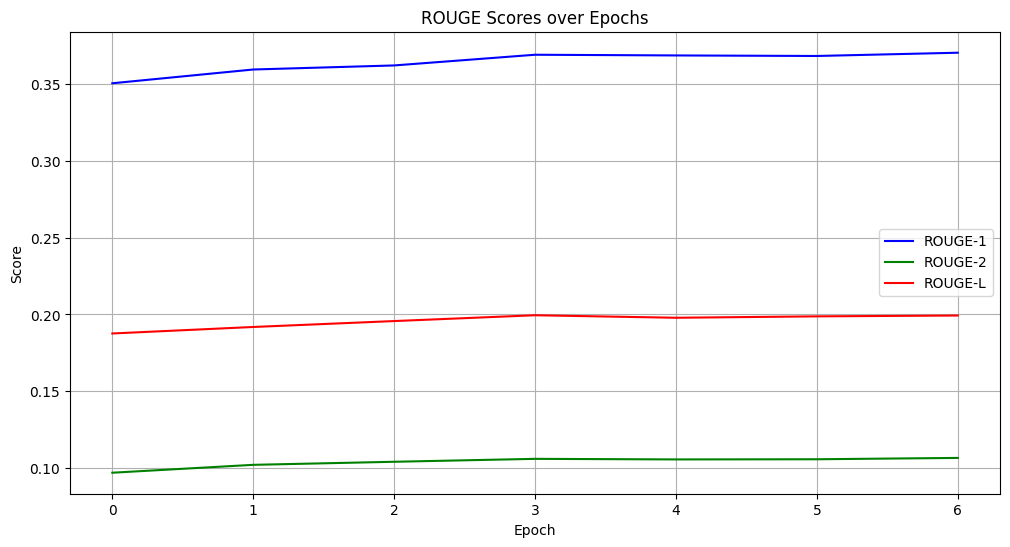

In [29]:
def plot_metrics(metrics_history):
    plt.figure(figsize=(12, 6))
    
    # Plot ROUGE-1
    plt.plot(metrics_history['rouge1'], label='ROUGE-1', color='blue')
    # Plot ROUGE-2
    plt.plot(metrics_history['rouge2'], label='ROUGE-2', color='green')
    # Plot ROUGE-L
    plt.plot(metrics_history['rougeL'], label='ROUGE-L', color='red')
    
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.title('ROUGE Scores over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

# Call the plot function after training
plot_metrics(metrics_history)


In [30]:
logging.info(f"Time: {result.metrics['train_runtime']:.2f}")
logging.info(f"Samples/second: {result.metrics['train_samples_per_second']:.2f}")

2024-08-26 20:34:42,101 - INFO - Time: 14651.31
2024-08-26 20:34:42,108 - INFO - Samples/second: 0.65


# saved the custom model

In [31]:
os.makedirs('trained', exist_ok=True)
trainer.save_model(f'trained/custom-led')

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 600, 'min_length': 100, 'early_stopping': True, 'num_beams': 2, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3}


# testing models

In [71]:

test_data = pd.read_json(f'test_dataset_{selected_approach}.json')
sample_data = random_row = test_data.sample(n=1)
pd.set_option('display.max_colwidth', None)
print(sample_data)
article_text = sample_data['Body'].iloc[0]
summerized = sample_data['Summary'].iloc[0]
file_name = sample_data['File'].iloc[0]



                                         File  \
196  article_data/PMC001xxxxxx/PMC1435753.xml   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [72]:
def summarize_text(model_name, tokenizer_name=None, text=article_text, min_length=100, max_length=300):
    if tokenizer_name is None:
        tokenizer_name = model_name
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    summarizer = pipeline("summarization", model=model, tokenizer=tokenizer, device=device)
    summary = summarizer(text, min_length=min_length, max_length=max_length)
    return summary[0]['summary_text']


In [73]:
# Summarize the text using Longformer
longformer_summary = summarize_text("cnicu/led-booksum")


Input ids are automatically padded from 815 to 1024 to be a multiple of `config.attention_window`: 1024


In [74]:
longformer_16384_summary = summarize_text("allenai/led-base-16384")

In [75]:
# Summarize the text using BigBird-Pegasus
bigbird_summary = summarize_text("google/bigbird-pegasus-large-arxiv")

Input ids are automatically padded from 731 to 768 to be a multiple of `config.block_size`: 64


In [76]:
custom_summary = summarize_text("trained/custom-led")

In [77]:
print("Original Article Text:")
print(article_text)
print("-"*30)
print("\nSummarized with Longformer(booksum):")
print(longformer_summary)
print("-"*30)
print("\nSummarized with Longformer(16384):")
print(longformer_16384_summary)
print("-"*30)
print("\nSummarized with BigBird-Pegasus:")
print(bigbird_summary)
print("-"*30)
print("\nSummarized with fine-tuned led:")
print(custom_summary)

Original Article Text:
Methods: Methods:
Ten consecutive males on a waiting list for ACL reconstructive surgery were recruited.
The inclusion of the ACL deficient patient was dependent upon them having a grade 2 or 3 ACL ligamentous laxity on manual testing, being at least 6 weeks post injury and the absence of other ligamentous involvement.
Ten gender and age-matched healthy Controls were recruited from the community through the use of flyers and word-of-mouth.
The ACLD patients were tested 5.3 to 60 months post injury and were similar in mean (+/- SEM) age in comparison to Controls (28.4 (+/- 2.74) and 28.4 (+/- 1.11) years respectively).
All ACLD patients demonstrated normal extension range of motion on the injured limb (less than 3-degree difference between limbs), seven had normal flexion (between 0 to 5-degree difference between limbs) and three had nearly normal flexion (between 6 to 15 degree difference between limbs).
None of the ACLD patients had evidence of swelling at the t

In [78]:
def evaluate_summaries(expected, summaries):
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity
    
    tfidf = TfidfVectorizer().fit_transform([expected] + summaries)
    cosine_similarities = cosine_similarity(tfidf[0:1], tfidf[1:]).flatten()
    
    for i, (summary, score) in enumerate(zip(summaries, cosine_similarities)):
        print(f"\nSummary {i+1}:")
        print(summary)
        print(f"Cosine Similarity with Original Text: {score:.4f}")
    

In [79]:
summaries = [longformer_summary, bigbird_summary, longformer_16384_summary, custom_summary]
evaluate_summaries(summerized, summaries)


Summary 1:
The ACLD patients were recruited from the community through the use of flyers and word-of-mouth. The ACLD patient is a man with a grade 2 or 3 ACL ligamentous laxity. He has a grade 3 or 3 ligamential laxity, which is a sign of ACL damage. He is also a man who has an ACL deficiency, which means he has no physical activity. He does not have any physical activity, and he does not exercise. He also does not use a stationary bike prior to testing. He and his wife, who is a nurse practitioner, are also volunteers. They are also not required to hold their landing position. The men are instructed to stand on one limb and hop as far forward as possible. They also do not have evidence of swelling at the time of testing. They do not wear their landing positions. They have no evidence of any swelling at all. They only have a slight limp on the injured limb, which indicates that they are not injured. The women who are recruited are all women, and they do not show any signs of swelling.